# 🔬 Experiment Set 3 — Missing Parameter Test
## Accuracy Drop Under Incomplete Specifications

---

## Dataset Used: `rfp_specs_missing_specs.csv` (Variant 5)

**Why this dataset and NOT the others:**

| Dataset | Why NOT used here |
|---|---|
| Numeric Perturbation (Exp 1) | Tests wrong values, not missing values |
| Unit Variation (Exp 2) | Tests notation changes, not absent fields |
| In/Out-of-domain noise | Tests irrelevant filler text |
| Long-doc | Tests attention over length |
| Positional shift | Tests where info appears, not if it appears |
| **Missing Specs (Variant 5)** | **Drops 1-4 token types from spec_text_raw: voltage, size, core, conductor, insulation, fire rating, armouring, standard. Tests: can models still match when the RFP is incomplete?** |

## What Was Removed
Only `spec_text_raw` is modified. All **9 structured columns remain correct**.

| Tokens Dropped | Rows | Example |
|---|---|---|
| Voltage | 2,251 (32.2%) | `11kV` removed |
| Size | 2,219 (31.7%) | `240 sqmm` removed |
| Core count | 2,294 (32.8%) | `3C` removed |
| Conductor | 2,257 (32.2%) | `Cu` / `Al` removed |
| Insulation | 2,197 (31.4%) | `XLPE` / `PVC` removed |
| Fire rating | 1,679 (24.0%) | `FRLS` / `FR` removed |
| Armouring | 2,312 (33.0%) | `armoured` removed |
| Standard ref | 2,312 (33.0%) | `as per IS 7098` removed |

Severity is evenly distributed: ~25% each of 1, 2, 3, and 4 token types dropped. 40.1% of rows drop at least one mandatory field.

## Core Hypothesis
- **SBERT** encodes `spec_text_raw` — missing tokens mean missing embedding signal → retrieval degrades, especially for highly specific specs
- **Hybrid** uses structured columns for its structured+standards score → immune to text omissions, degrades only in the semantic component (30% weight)

## Metrics
1. **Accuracy Drop %** — ΔTop-1, ΔMRR, ΔNDCG@5 (clean → missing)
2. **Severity-Stratified Accuracy** — how does performance scale with 1/2/3/4 dropped tokens?
3. **Mandatory vs Non-Mandatory Drop Impact** — does dropping a mandatory field hurt more?
4. **Field-Specific Drop Impact** — which field, when dropped, hurts which model most?
5. **Robustness Score** — retained performance % vs all baselines

In [ ]:
# CELL 1 — INSTALL
!pip install -q sentence-transformers scikit-learn rank-bm25 pandas numpy matplotlib tabulate pyarrow

In [ ]:
# CELL 2 — IMPORTS
import os, json, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Dict, Optional, Tuple, List
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

warnings.filterwarnings('ignore')
np.random.seed(42)

ARTIFACT_DIR = 'obj1_model_artifacts'
EXP_DIR      = 'exp3_missing_params'
os.makedirs(EXP_DIR, exist_ok=True)
print('✅ Imports done.')

✅ Imports done.


In [ ]:
# CELL 3 — LOAD ARTIFACTS + DATASETS
# Upload to Colab:
#   obj1_model_artifacts/           (from Objective 1)
#   rfp_specs_7000.csv              (clean baseline)
#   rfp_specs_missing_specs.csv     (Variant 5 — THIS experiment)
#   product_catalog.csv

cfg         = json.load(open(f'{ARTIFACT_DIR}/model_config.json'))
product_df  = pd.read_parquet(f'{ARTIFACT_DIR}/product_df.parquet')
rfp_gt_df   = pd.read_parquet(f'{ARTIFACT_DIR}/rfp_df_with_gt.parquet')
product_emb = np.load(f'{ARTIFACT_DIR}/product_embeddings_mpnet.npy')
baseline_df = pd.read_csv(f'{ARTIFACT_DIR}/baseline_results.csv')

df_clean   = pd.read_csv('rfp_specs_7000.csv').reset_index(drop=True)
df_missing = pd.read_csv('rfp_specs_missing_specs.csv').reset_index(drop=True)

for df in [df_clean, df_missing, product_df]:
    df.columns = df.columns.str.strip()

gt_lookup = (
    rfp_gt_df.dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

N_RFP = len(df_clean)
N_SKU = len(product_df)
K     = cfg['K']

print(f'Product catalog      : {product_df.shape}')
print(f'Clean RFP specs      : {df_clean.shape}')
print(f'Missing specs        : {df_missing.shape}')
print(f'GT entries           : {len(gt_lookup)}')
print(f'K                    : {K}')
print(f'Hybrid weights       : {cfg["hybrid_weights"]}')
print('\nObj 1 Baseline (reference):')
print(baseline_df[['Model','Top-1 Acc','MRR','NDCG@5']].to_string(index=False))

Product catalog      : (200, 16)
Clean RFP specs      : (7000, 17)
Missing specs        : (7000, 17)
GT entries           : 7000
K                    : 5
Hybrid weights       : {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2}

Obj 1 Baseline (reference):
                    Model  Top-1 Acc      MRR   NDCG@5
       1. Random Baseline   0.004571 0.029806 0.016021
       2. TF-IDF + Cosine   0.115429 0.231303 0.220847
          3. BM25 (Okapi)   0.055857 0.165056 0.148266
       4. SBERT MiniLM-L6   0.132571 0.231357 0.231525
5. SBERT MPNet (sem-only)   0.165286 0.260932 0.248361
6. Exact Structured Match   0.057000 0.129356 0.116747
       7. 🏆 Hybrid (Ours)   0.178000 0.308767 0.312451


In [ ]:
# CELL 4 — SEVERITY TAGGING
# Tag every RFP row with which token types were dropped
# and how many (severity 1-4)

TOKEN_PATTERNS = {
    'voltage':    r'\b\d+(?:\.\d+)?(?:kV|V)\b',
    'size_sqmm':  r'\b\d+(?:\.\d+)?\s*sqmm\b',
    'core_count': r'\b\d+C\b',
    'conductor':  r'\b(Cu|Al)\b',
    'insulation': r'\b(XLPE|PVC|EPR)\b',
    'fire_rating':r'\b(FRLS|FR|LSZH|ZH|Fire Survival)\b',
    'armouring':  r'\b(armoured)\b',
    'standard':   r'\bas per\s+[\w\s\-]+\d[\w\-]*',
}

# Map token categories to structured column names
TOKEN_TO_FIELD = {
    'voltage':    'voltage_rating',
    'core_count': 'core_count',
    'size_sqmm':  'size_sqmm',
    'conductor':  'conductor_material',
    'insulation': 'insulation_type',
}

sev_rows = []
for i in range(N_RFP):
    orig = str(df_clean.loc[i, 'spec_text_raw'])
    pert = str(df_missing.loc[i, 'spec_text_raw'])
    dropped = []
    for k, pat in TOKEN_PATTERNS.items():
        if len(re.findall(pat, orig)) > len(re.findall(pat, pert)):
            dropped.append(k)
    # Check if any mandatory field was dropped
    mandatory_raw = str(df_clean.loc[i, 'mandatory_specs'] or '')
    mandatory = set(f.strip() for f in mandatory_raw.split(';') if f.strip())
    dropped_fields = {TOKEN_TO_FIELD.get(d, d) for d in dropped}
    mandatory_hit  = bool(mandatory & dropped_fields)
    sev_rows.append({
        'rfp_id':        df_clean.loc[i, 'rfp_id'],
        'dropped':       dropped,
        'n_dropped':     len(dropped),
        'mandatory_hit': mandatory_hit,
        'voltage_drop':  'voltage'    in dropped,
        'size_drop':     'size_sqmm'  in dropped,
        'core_drop':     'core_count' in dropped,
        'conductor_drop':'conductor'  in dropped,
        'insulation_drop':'insulation' in dropped,
        'fire_drop':     'fire_rating' in dropped,
        'armouring_drop':'armouring'  in dropped,
        'standard_drop': 'standard'   in dropped,
    })

sev_df = pd.DataFrame(sev_rows)

print('=== Severity Distribution ===')
for n, cnt in sev_df['n_dropped'].value_counts().sort_index().items():
    print(f'  {n} fields dropped: {cnt:5d} rows ({cnt/N_RFP*100:.1f}%)')
print(f'\nRows where a mandatory field was dropped: {sev_df.mandatory_hit.sum()} '
      f'({sev_df.mandatory_hit.mean()*100:.1f}%)')
print('\nPer-field drop counts:')
field_cols = ['voltage_drop','size_drop','core_drop','conductor_drop',
              'insulation_drop','fire_drop','armouring_drop','standard_drop']
for col in field_cols:
    cnt = sev_df[col].sum()
    print(f'  {col:20s}: {cnt:5d} ({cnt/N_RFP*100:.1f}%)')
print('\n✅ Severity tagging done.')

=== Severity Distribution ===
  1 fields dropped:  1744 rows (24.9%)
  2 fields dropped:  1745 rows (24.9%)
  3 fields dropped:  1757 rows (25.1%)
  4 fields dropped:  1754 rows (25.1%)

Rows where a mandatory field was dropped: 2810 (40.1%)

Per-field drop counts:
  voltage_drop        :  2251 (32.2%)
  size_drop           :  2219 (31.7%)
  core_drop           :  2294 (32.8%)
  conductor_drop      :  2257 (32.2%)
  insulation_drop     :  2197 (31.4%)
  fire_drop           :  1679 (24.0%)
  armouring_drop      :  2312 (33.0%)
  standard_drop       :  2312 (33.0%)

✅ Severity tagging done.


In [ ]:
# CELL 5 — SHARED SCORING FUNCTIONS
_SIZE_LADDER = [0.5,0.75,1.0,1.5,2.5,4.0,6.0,10.0,16.0,25.0,35.0,50.0,70.0,95.0,
                120.0,150.0,185.0,240.0,300.0,400.0,500.0,630.0,800.0,1000.0]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val):
    if val not in _SIZE_SET: val = min(_SIZE_LADDER, key=lambda x: abs(x-val))
    idx = _SIZE_LADDER.index(val)
    n = {val}
    if idx > 0: n.add(_SIZE_LADDER[idx-1])
    if idx < len(_SIZE_LADDER)-1: n.add(_SIZE_LADDER[idx+1])
    return n

def structured_score(rfp_row, sku_row):
    mandatory = set(f.strip() for f in str(rfp_row.get('mandatory_specs','')).split(';') if f.strip())
    score = total = 0.0
    for field in cfg['exact_fields']:
        w = 2.0 if field in mandatory else 1.0
        total += w
        if str(rfp_row.get(field,'')).strip().lower() == str(sku_row.get(field,'')).strip().lower():
            score += w
    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])): score += w_cc
    except: pass
    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        if float(sku_row['size_sqmm']) in _adjacent_sizes(float(rfp_row['size_sqmm'])): score += w_sz
    except: pass
    return score/total if total > 0 else 0.0

def standards_score(rfp_row, sku_row):
    r = str(rfp_row.get('standards_required','')).strip().lower()
    s = str(sku_row.get('standards_complied','')).strip().lower()
    if not r or r == 'nan': return 0.0
    return 1.0 if (r in s or s in r) else 0.0

def compute_metrics(match_groups, gt_lookup, score_key='hybrid', weights=None, K=5):
    top1 = topk = mrr_sum = prec_sum = ndcg_sum = 0.0; evaluated = 0
    for rfp_id, grp in match_groups.items():
        gt = gt_lookup.get(rfp_id)
        if gt is None: continue
        sku_ids = grp['sku_id']
        if weights:
            ws, we, wt = weights
            scores = ws*grp['structured'] + we*grp['semantic'] + wt*grp['standards']
        else:
            scores = grp[score_key]
        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]
        pos    = np.where(ranked == gt)[0]
        if len(pos) == 0: continue
        rank = int(pos[0]) + 1; evaluated += 1
        if rank == 1: top1 += 1
        if rank <= K:
            topk += 1; prec_sum += 1.0/K; ndcg_sum += 1.0/np.log2(rank+1)
        mrr_sum += 1.0/rank
    if evaluated == 0:
        return {m: 0.0 for m in ['Top-1 Acc','Top-5 Acc','Recall@5','MRR','Precision@5','NDCG@5']}
    ideal = 1.0/np.log2(2)
    return {'Top-1 Acc': top1/evaluated, 'Top-5 Acc': topk/evaluated,
            'Recall@5': topk/evaluated, 'MRR': mrr_sum/evaluated,
            'Precision@5': prec_sum/evaluated, 'NDCG@5': (ndcg_sum/evaluated)/ideal}

def build_groups(mdf):
    groups = {}
    for rfp_id, grp in mdf.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'structured': grp['Structured_Score'].to_numpy(np.float32),
            'semantic':   grp['Semantic_Score'].to_numpy(np.float32),
            'standards':  grp['Standards_Score'].to_numpy(np.float32),
            'hybrid':     grp['Hybrid_Score'].to_numpy(np.float32),
            'tfidf':      grp['TFIDF_Score'].to_numpy(np.float32),
            'bm25':       grp['BM25_Score'].to_numpy(np.float32),
            'minilm':     grp['MiniLM_Score'].to_numpy(np.float32),
        }
    return groups

print('✅ Scoring functions defined.')

✅ Scoring functions defined.


In [ ]:
# CELL 6 — ENCODE BOTH DATASETS WITH ALL MODELS
clean_texts   = df_clean['spec_text_raw'].astype(str).tolist()
missing_texts = df_missing['spec_text_raw'].astype(str).tolist()
prod_texts    = product_df['product_name'].astype(str).tolist()

print('Loading MPNet...')
t0 = time.time()
mpnet = SentenceTransformer('all-mpnet-base-v2')
clean_emb_mpnet   = mpnet.encode(clean_texts,   batch_size=64, normalize_embeddings=True, show_progress_bar=True)
missing_emb_mpnet = mpnet.encode(missing_texts, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
sem_clean   = (clean_emb_mpnet   @ product_emb.T).astype(np.float32)
sem_missing = (missing_emb_mpnet @ product_emb.T).astype(np.float32)
print(f'MPNet done in {time.time()-t0:.1f}s')

print('\nLoading MiniLM...')
t1 = time.time()
minilm = SentenceTransformer('all-MiniLM-L6-v2')
prod_emb_mini       = minilm.encode(prod_texts,    batch_size=128, normalize_embeddings=True)
clean_emb_mini      = minilm.encode(clean_texts,   batch_size=128, normalize_embeddings=True, show_progress_bar=True)
missing_emb_mini    = minilm.encode(missing_texts, batch_size=128, normalize_embeddings=True, show_progress_bar=True)
sem_clean_mini   = (clean_emb_mini   @ prod_emb_mini.T).astype(np.float32)
sem_missing_mini = (missing_emb_mini @ prod_emb_mini.T).astype(np.float32)
print(f'MiniLM done in {time.time()-t1:.1f}s')

print('\nComputing TF-IDF...')
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
tfidf.fit(clean_texts + missing_texts + prod_texts)
prod_tfidf       = tfidf.transform(prod_texts)
tfidf_clean_mat  = (tfidf.transform(clean_texts)   @ prod_tfidf.T).toarray().astype(np.float32)
tfidf_miss_mat   = (tfidf.transform(missing_texts) @ prod_tfidf.T).toarray().astype(np.float32)
print('TF-IDF done.')

print('Computing BM25...')
t2 = time.time()
bm25_model = BM25Okapi([t.lower().split() for t in prod_texts])
def bm25_mat(texts):
    mat = np.zeros((len(texts), N_SKU), np.float32)
    for i, t in enumerate(texts):
        sc = bm25_model.get_scores(t.lower().split()).astype(np.float32)
        mx = sc.max()
        mat[i] = sc/mx if mx > 0 else sc
    return mat
bm25_clean_mat = bm25_mat(clean_texts)
bm25_miss_mat  = bm25_mat(missing_texts)
print(f'BM25 done in {time.time()-t2:.1f}s')

Loading MPNet...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

MiniLM done in 7.9s

Computing TF-IDF...
TF-IDF done.
Computing BM25...
BM25 done in 6.0s


In [ ]:
# CELL 7 — BUILD MATCH MATRICES
# Structured + standards scores IDENTICAL (structural columns unchanged)
print('Computing structured + standards scores...')
t0 = time.time()
struct_mat = np.zeros((N_RFP, N_SKU), np.float32)
std_mat    = np.zeros((N_RFP, N_SKU), np.float32)
for i, rfp_row in df_clean.iterrows():
    for j, sku_row in product_df.iterrows():
        struct_mat[i,j] = structured_score(rfp_row, sku_row)
        std_mat[i,j]    = standards_score(rfp_row, sku_row)
print(f'Done in {time.time()-t0:.1f}s')

W  = cfg['hybrid_weights']
ws, we, wt = W['structured'], W['semantic'], W['standards']

def build_match_df(rfp_source, sem_mpnet, sem_mini, tfidf_m, bm25_m, label):
    rows = []
    rfp_ids = rfp_source['rfp_id'].values
    sku_ids = product_df['sku_id'].values
    for i in range(N_RFP):
        for j in range(N_SKU):
            hybrid = ws*struct_mat[i,j] + we*float(sem_mpnet[i,j]) + wt*std_mat[i,j]
            rows.append((rfp_ids[i], sku_ids[j], struct_mat[i,j], float(sem_mpnet[i,j]),
                         float(sem_mini[i,j]), float(tfidf_m[i,j]), float(bm25_m[i,j]),
                         std_mat[i,j], hybrid))
    mdf = pd.DataFrame(rows, columns=[
        'RFP_ID','SKU_ID','Structured_Score','Semantic_Score',
        'MiniLM_Score','TFIDF_Score','BM25_Score','Standards_Score','Hybrid_Score'])
    print(f'  [{label}] shape: {mdf.shape}')
    return mdf

print('Building clean match matrix...')
match_clean   = build_match_df(df_clean,   sem_clean,   sem_clean_mini,   tfidf_clean_mat, bm25_clean_mat, 'clean')
print('Building missing-spec match matrix...')
match_missing = build_match_df(df_missing, sem_missing, sem_missing_mini, tfidf_miss_mat,  bm25_miss_mat,  'missing')

groups_clean   = build_groups(match_clean)
groups_missing = build_groups(match_missing)
print('✅ Match groups built.')

Computing structured + standards scores...
Done in 128.2s
Building clean match matrix...
  [clean] shape: (1400000, 9)
Building missing-spec match matrix...
  [missing] shape: (1400000, 9)
✅ Match groups built.


In [ ]:
# CELL 8 — METRIC 1: OVERALL IR METRICS (Clean vs Missing)
# This gives the headline accuracy drop % for every model
all_model_configs = [
    ('Random Baseline',        'random',    None),
    ('TF-IDF + Cosine',        'tfidf',     None),
    ('BM25 (Okapi)',           'bm25',      None),
    ('SBERT MiniLM-L6',        'minilm',    None),
    ('SBERT MPNet (sem-only)', 'semantic',  None),
    ('Exact Structured',       'structured',None),
    ('Hybrid (Ours)',          'hybrid',    None),
]

rng = np.random.default_rng(42)
def add_random(groups):
    rg = {}
    for k, v in groups.items():
        rg[k] = {**v, 'random': rng.random(len(v['sku_id'])).astype(np.float32)}
    return rg

rg_clean   = add_random(groups_clean)
rg_missing = add_random(groups_missing)

ir_rows = []
for label, score_key, weights in all_model_configs:
    gc = rg_clean   if score_key == 'random' else groups_clean
    gm = rg_missing if score_key == 'random' else groups_missing
    mc = compute_metrics(gc, gt_lookup, score_key=score_key, weights=weights, K=K)
    mm = compute_metrics(gm, gt_lookup, score_key=score_key, weights=weights, K=K)
    t1_drop   = (mm['Top-1 Acc'] - mc['Top-1 Acc']) / mc['Top-1 Acc'] * 100 if mc['Top-1 Acc'] > 0 else 0
    mrr_drop  = (mm['MRR']       - mc['MRR'])       / mc['MRR']       * 100 if mc['MRR']       > 0 else 0
    ndcg_drop = (mm['NDCG@5']    - mc['NDCG@5'])    / mc['NDCG@5']    * 100 if mc['NDCG@5']    > 0 else 0
    ir_rows.append({
        'Model':              label,
        'Top-1 (Clean)':      mc['Top-1 Acc'],
        'Top-1 (Missing)':    mm['Top-1 Acc'],
        'Δ Top-1':            mm['Top-1 Acc'] - mc['Top-1 Acc'],
        'Accuracy Drop %':    t1_drop,
        'Top-5 (Clean)':      mc['Top-5 Acc'],
        'Top-5 (Missing)':    mm['Top-5 Acc'],
        'Δ Top-5':            mm['Top-5 Acc'] - mc['Top-5 Acc'],
        'MRR (Clean)':        mc['MRR'],
        'MRR (Missing)':      mm['MRR'],
        'Δ MRR':              mm['MRR'] - mc['MRR'],
        'MRR Drop %':         mrr_drop,
        'NDCG@5 (Clean)':     mc['NDCG@5'],
        'NDCG@5 (Missing)':   mm['NDCG@5'],
        'Δ NDCG@5':           mm['NDCG@5'] - mc['NDCG@5'],
        'NDCG Drop %':        ndcg_drop,
    })

ir_df = pd.DataFrame(ir_rows)

print('\n' + '='*115)
print('  IR Metrics: Clean vs Missing Specs (negative Δ = degraded)')
print('='*115)
print(ir_df[['Model','Top-1 (Clean)','Top-1 (Missing)','Δ Top-1','Accuracy Drop %',
              'MRR (Clean)','MRR (Missing)','Δ MRR','NDCG@5 (Clean)','NDCG@5 (Missing)','Δ NDCG@5']]
      .to_markdown(index=False, floatfmt='.4f'))
print()
print('Accuracy Drop % (Top-1):')
for _, row in ir_df.iterrows():
    print(f'  {row.Model:35s}: {row["Accuracy Drop %"]:+.1f}%')


  IR Metrics: Clean vs Missing Specs (negative Δ = degraded)
| Model                  |   Top-1 (Clean) |   Top-1 (Missing) |   Δ Top-1 |   Accuracy Drop % |   MRR (Clean) |   MRR (Missing) |   Δ MRR |   NDCG@5 (Clean) |   NDCG@5 (Missing) |   Δ NDCG@5 |
|:-----------------------|----------------:|------------------:|----------:|------------------:|--------------:|----------------:|--------:|-----------------:|-------------------:|-----------:|
| Random Baseline        |          0.0046 |            0.0054 |    0.0009 |           18.7500 |        0.0298 |          0.0299 |  0.0001 |           0.0160 |             0.0147 |    -0.0013 |
| TF-IDF + Cosine        |          0.1147 |            0.0660 |   -0.0487 |          -42.4658 |        0.2344 |          0.1549 | -0.0796 |           0.2267 |             0.1416 |    -0.0851 |
| BM25 (Okapi)           |          0.0559 |            0.0477 |   -0.0081 |          -14.5780 |        0.1651 |          0.1312 | -0.0339 |           0.1483 |   

In [ ]:
# CELL 9 — METRIC 2: SEVERITY-STRATIFIED ACCURACY
# How does performance degrade as more fields are dropped?
# Segments: 0 dropped / 1 dropped / 2 dropped / 3 dropped / 4 dropped

rfp_to_severity = sev_df.set_index('rfp_id')['n_dropped'].to_dict()

severity_rows = []
for n_drop in [0, 1, 2, 3, 4]:
    # Filter GT lookup to only RFPs in this severity bucket
    gt_sub = {rfp: sku for rfp, sku in gt_lookup.items()
              if rfp_to_severity.get(rfp, 0) == n_drop}
    if not gt_sub:
        continue
    for label, score_key, _ in all_model_configs:
        gm = rg_missing if score_key == 'random' else groups_missing
        m  = compute_metrics(gm, gt_sub, score_key=score_key, K=K)
        severity_rows.append({
            'n_dropped': n_drop,
            'Model':     label,
            'Top-1':     m['Top-1 Acc'],
            'MRR':       m['MRR'],
            'NDCG@5':    m['NDCG@5'],
            'n_rfps':    len(gt_sub),
        })

sev_metrics = pd.DataFrame(severity_rows)

print('\n' + '='*90)
print('  Severity-Stratified Metrics on MISSING data (by # fields dropped)')
print('='*90)
for n_drop in [0, 1, 2, 3, 4]:
    sub = sev_metrics[sev_metrics['n_dropped'] == n_drop]
    if len(sub) == 0: continue
    n = sub.iloc[0]['n_rfps']
    print(f'\n  --- {n_drop} fields dropped (n={n} RFPs) ---')
    print(sub[['Model','Top-1','MRR','NDCG@5']].to_markdown(index=False, floatfmt='.4f'))


  Severity-Stratified Metrics on MISSING data (by # fields dropped)

  --- 1 fields dropped (n=1744 RFPs) ---
| Model                  |   Top-1 |    MRR |   NDCG@5 |
|:-----------------------|--------:|-------:|---------:|
| Random Baseline        |  0.0075 | 0.0308 |   0.0152 |
| TF-IDF + Cosine        |  0.0935 | 0.2033 |   0.1945 |
| BM25 (Okapi)           |  0.0562 | 0.1530 |   0.1339 |
| SBERT MiniLM-L6        |  0.1135 | 0.2017 |   0.1952 |
| SBERT MPNet (sem-only) |  0.1267 | 0.2302 |   0.2215 |
| Exact Structured       |  0.0516 | 0.1245 |   0.1145 |
| Hybrid (Ours)          |  0.1674 | 0.3007 |   0.3060 |

  --- 2 fields dropped (n=1745 RFPs) ---
| Model                  |   Top-1 |    MRR |   NDCG@5 |
|:-----------------------|--------:|-------:|---------:|
| Random Baseline        |  0.0029 | 0.0284 |   0.0129 |
| TF-IDF + Cosine        |  0.0768 | 0.1724 |   0.1621 |
| BM25 (Okapi)           |  0.0544 | 0.1435 |   0.1302 |
| SBERT MiniLM-L6        |  0.0928 | 0.1700 |   0

In [ ]:
# CELL 10 — METRIC 3: MANDATORY vs NON-MANDATORY DROP IMPACT
# Does dropping a field that the RFP marked as 'mandatory' cause
# more damage than dropping a non-mandatory field?

rfp_to_mandatory_hit = sev_df.set_index('rfp_id')['mandatory_hit'].to_dict()

mand_rows = []
for mand_hit in [False, True]:
    gt_sub = {rfp: sku for rfp, sku in gt_lookup.items()
              if rfp_to_mandatory_hit.get(rfp, False) == mand_hit}
    if not gt_sub: continue
    for label, score_key, _ in all_model_configs:
        gm = rg_missing if score_key == 'random' else groups_missing
        m  = compute_metrics(gm, gt_sub, score_key=score_key, K=K)
        mand_rows.append({
            'Mandatory Hit': 'Yes (mandatory dropped)' if mand_hit else 'No (non-mandatory only)',
            'Model': label, 'Top-1': m['Top-1 Acc'],
            'MRR': m['MRR'], 'NDCG@5': m['NDCG@5'], 'n_rfps': len(gt_sub),
        })

mand_df = pd.DataFrame(mand_rows)

print('\n' + '='*90)
print('  Mandatory vs Non-Mandatory Field Drop Impact')
print('='*90)
for hit_label in mand_df['Mandatory Hit'].unique():
    sub = mand_df[mand_df['Mandatory Hit'] == hit_label]
    n = sub.iloc[0]['n_rfps']
    print(f'\n  [{hit_label}]  (n={n} RFPs)')
    print(sub[['Model','Top-1','MRR','NDCG@5']].to_markdown(index=False, floatfmt='.4f'))


  Mandatory vs Non-Mandatory Field Drop Impact

  [No (non-mandatory only)]  (n=4190 RFPs)
| Model                  |   Top-1 |    MRR |   NDCG@5 |
|:-----------------------|--------:|-------:|---------:|
| Random Baseline        |  0.0057 | 0.0299 |   0.0148 |
| TF-IDF + Cosine        |  0.0680 | 0.1632 |   0.1516 |
| BM25 (Okapi)           |  0.0461 | 0.1321 |   0.1168 |
| SBERT MiniLM-L6        |  0.0871 | 0.1640 |   0.1550 |
| SBERT MPNet (sem-only) |  0.1100 | 0.2041 |   0.1951 |
| Exact Structured       |  0.0556 | 0.1266 |   0.1150 |
| Hybrid (Ours)          |  0.1578 | 0.2853 |   0.2854 |

  [Yes (mandatory dropped)]  (n=2810 RFPs)
| Model                  |   Top-1 |    MRR |   NDCG@5 |
|:-----------------------|--------:|-------:|---------:|
| Random Baseline        |  0.0050 | 0.0299 |   0.0145 |
| TF-IDF + Cosine        |  0.0630 | 0.1425 |   0.1267 |
| BM25 (Okapi)           |  0.0502 | 0.1298 |   0.1189 |
| SBERT MiniLM-L6        |  0.0680 | 0.1398 |   0.1316 |
| SBERT M

In [ ]:
# CELL 11 — METRIC 4: PER-FIELD DROP IMPACT
# For each field type, isolate the RFPs that dropped ONLY that field
# and measure SBERT vs Hybrid performance on that subset

FIELD_COLS = {
    'Voltage dropped':    'voltage_drop',
    'Size dropped':       'size_drop',
    'Core count dropped': 'core_drop',
    'Conductor dropped':  'conductor_drop',
    'Insulation dropped': 'insulation_drop',
    'Fire rating dropped':'fire_drop',
    'Armouring dropped':  'armouring_drop',
    'Standard dropped':   'standard_drop',
}

field_rows = []
focused_models = [
    ('SBERT MPNet (sem-only)', 'semantic'),
    ('Hybrid (Ours)',          'hybrid'),
]
for field_label, col in FIELD_COLS.items():
    rfp_ids_with_drop = set(sev_df[sev_df[col]]['rfp_id'])
    gt_sub = {rfp: sku for rfp, sku in gt_lookup.items() if rfp in rfp_ids_with_drop}
    if not gt_sub: continue
    for model_name, score_key in focused_models:
        mc = compute_metrics(groups_clean,   gt_sub, score_key=score_key, K=K)
        mm = compute_metrics(groups_missing, gt_sub, score_key=score_key, K=K)
        drop_pct = (mm['Top-1 Acc'] - mc['Top-1 Acc']) / mc['Top-1 Acc'] * 100 if mc['Top-1 Acc'] > 0 else 0
        field_rows.append({
            'Field Dropped': field_label,
            'Model':         model_name,
            'Top-1 Clean':   mc['Top-1 Acc'],
            'Top-1 Missing': mm['Top-1 Acc'],
            'Accuracy Drop %': drop_pct,
            'MRR Clean':     mc['MRR'],
            'MRR Missing':   mm['MRR'],
            'n_rfps':        len(gt_sub),
        })

field_df = pd.DataFrame(field_rows)

print('\n' + '='*100)
print('  Per-Field Drop Impact: SBERT vs Hybrid (Accuracy Drop % = negative means degraded)')
print('='*100)
print(field_df.to_markdown(index=False, floatfmt='.4f'))


  Per-Field Drop Impact: SBERT vs Hybrid (Accuracy Drop % = negative means degraded)
| Field Dropped       | Model                  |   Top-1 Clean |   Top-1 Missing |   Accuracy Drop % |   MRR Clean |   MRR Missing |   n_rfps |
|:--------------------|:-----------------------|--------------:|----------------:|------------------:|------------:|--------------:|---------:|
| Voltage dropped     | SBERT MPNet (sem-only) |        0.1746 |          0.0520 |          -70.2290 |      0.2726 |        0.1210 |     2251 |
| Voltage dropped     | Hybrid (Ours)          |        0.1768 |          0.1355 |          -23.3668 |      0.3092 |        0.2646 |     2251 |
| Size dropped        | SBERT MPNet (sem-only) |        0.1712 |          0.1181 |          -31.0526 |      0.2663 |        0.2056 |     2219 |
| Size dropped        | Hybrid (Ours)          |        0.1821 |          0.1591 |          -12.6238 |      0.3098 |        0.2879 |     2219 |
| Core count dropped  | SBERT MPNet (sem-only) |  

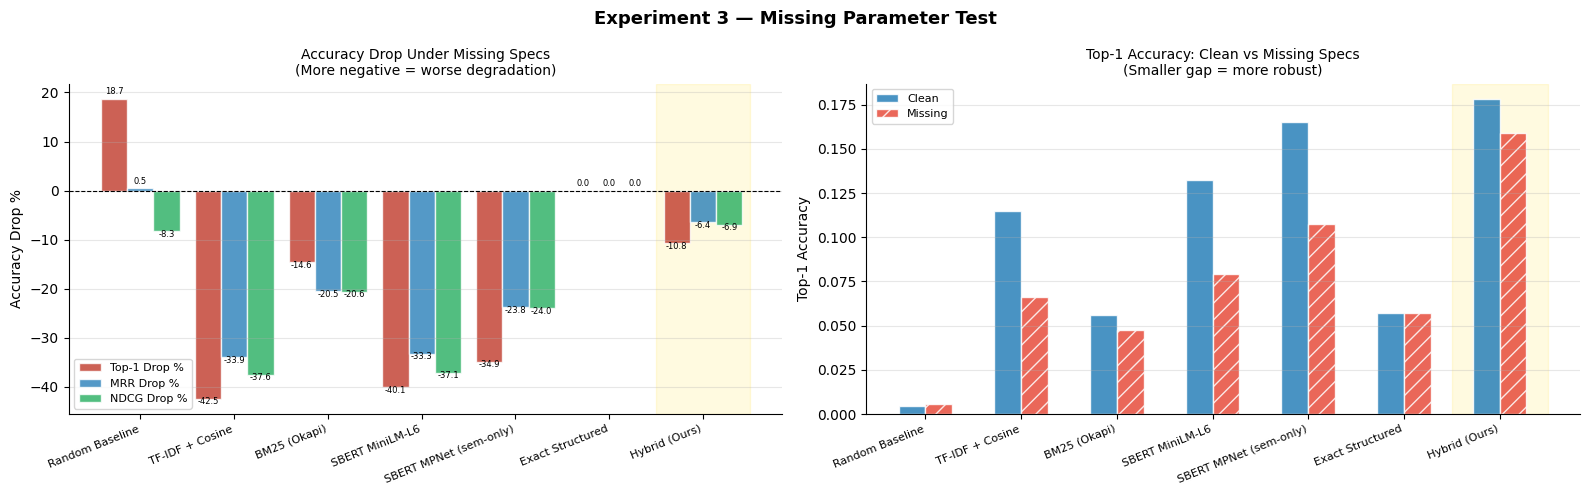

✅ Saved exp3_accuracy_drop.png


In [ ]:
# CELL 12 — VISUALISATION 1: ACCURACY DROP % BAR CHART
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models   = ir_df['Model'].tolist()
drop_t1  = ir_df['Accuracy Drop %'].values
drop_mrr = ir_df['MRR Drop %'].values
drop_ndcg= ir_df['NDCG Drop %'].values
x = np.arange(len(models))
w = 0.28
colors_neg = ['#2ecc71' if 'Hybrid' in m else '#e74c3c' for m in models]

# Plot 1: Accuracy Drop %
bars1 = axes[0].bar(x-w, drop_t1,   w, label='Top-1 Drop %', color='#c0392b', alpha=0.8, edgecolor='white')
bars2 = axes[0].bar(x,   drop_mrr,  w, label='MRR Drop %',   color='#2980b9', alpha=0.8, edgecolor='white')
bars3 = axes[0].bar(x+w, drop_ndcg, w, label='NDCG Drop %',  color='#27ae60', alpha=0.8, edgecolor='white')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x()+bar.get_width()/2, h + (0.5 if h>=0 else -1.5),
                     f'{h:.1f}', ha='center', va='bottom', fontsize=6)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
hybrid_x = [i for i, m in enumerate(models) if 'Hybrid' in m][0]
axes[0].axvspan(hybrid_x-0.5, hybrid_x+0.5, color='gold', alpha=0.12, zorder=0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=22, ha='right', fontsize=8)
axes[0].set_ylabel('Accuracy Drop %')
axes[0].set_title('Accuracy Drop Under Missing Specs\n(More negative = worse degradation)', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Plot 2: Clean vs Missing Top-1 side by side
t1_clean = ir_df['Top-1 (Clean)'].values
t1_miss  = ir_df['Top-1 (Missing)'].values
axes[1].bar(x-w/2, t1_clean, w, label='Clean',   color='#2980b9', alpha=0.85, edgecolor='white')
axes[1].bar(x+w/2, t1_miss,  w, label='Missing', color='#e74c3c', alpha=0.85, edgecolor='white', hatch='//')
axes[1].axvspan(hybrid_x-0.5, hybrid_x+0.5, color='gold', alpha=0.12, zorder=0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=22, ha='right', fontsize=8)
axes[1].set_ylabel('Top-1 Accuracy')
axes[1].set_title('Top-1 Accuracy: Clean vs Missing Specs\n(Smaller gap = more robust)', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 3 — Missing Parameter Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp3_accuracy_drop.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp3_accuracy_drop.png')

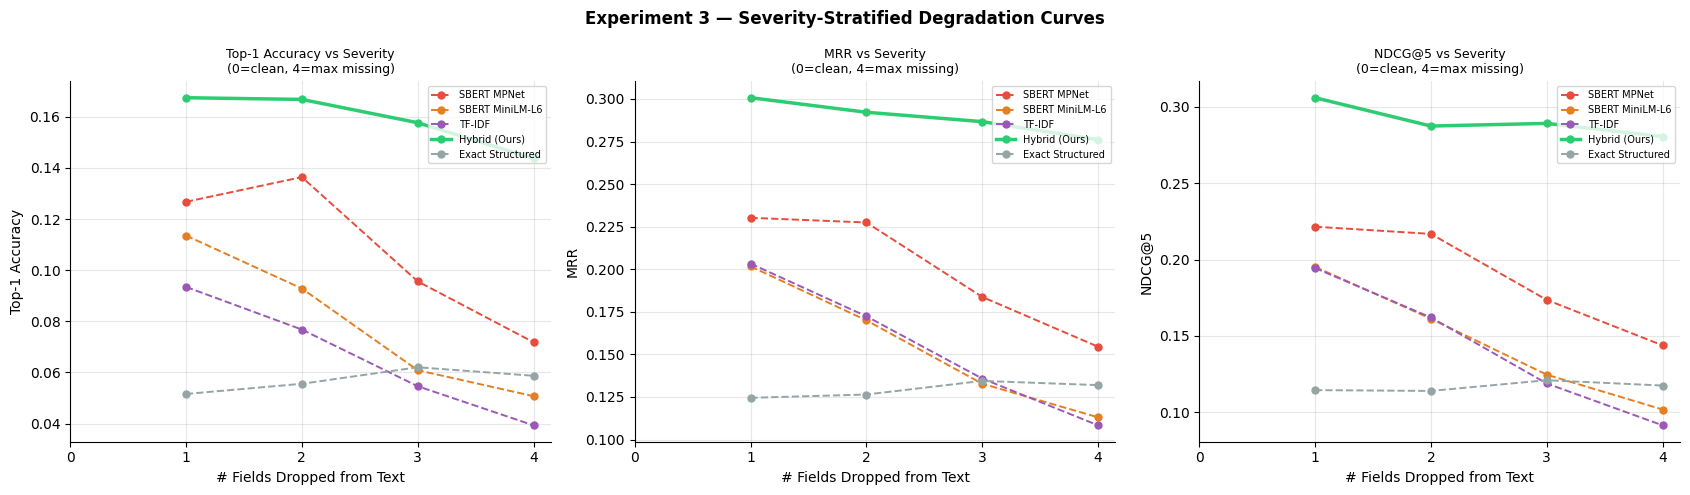

✅ Saved exp3_severity_curves.png


In [ ]:
# CELL 13 — VISUALISATION 2: SEVERITY DEGRADATION CURVES
# Top-1 accuracy vs number of dropped fields for key models
focus_models = ['SBERT MPNet (sem-only)', 'SBERT MiniLM-L6',
                'TF-IDF + Cosine', 'Hybrid (Ours)', 'Exact Structured']
colors_map = {
    'SBERT MPNet (sem-only)': '#e74c3c',
    'SBERT MiniLM-L6':        '#e67e22',
    'TF-IDF + Cosine':        '#9b59b6',
    'Hybrid (Ours)':          '#2ecc71',
    'Exact Structured':       '#95a5a6',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for metric, metric_label, ax in [
    ('Top-1', 'Top-1 Accuracy',  axes[0]),
    ('MRR',   'MRR',             axes[1]),
    ('NDCG@5','NDCG@5',          axes[2]),
]:
    for model in focus_models:
        sub = sev_metrics[sev_metrics['Model'] == model].sort_values('n_dropped')
        if len(sub) == 0: continue
        lw  = 2.5 if 'Hybrid' in model else 1.4
        ls  = '-'  if 'Hybrid' in model else '--'
        ax.plot(sub['n_dropped'], sub[metric], color=colors_map.get(model,'grey'),
                lw=lw, ls=ls, marker='o', ms=5, label=model.replace(' (sem-only)','').replace(' + Cosine',''))
    ax.set_xlabel('# Fields Dropped from Text')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} vs Severity\n(0=clean, 4=max missing)', fontsize=9)
    ax.set_xticks([0,1,2,3,4])
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 3 — Severity-Stratified Degradation Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp3_severity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp3_severity_curves.png')

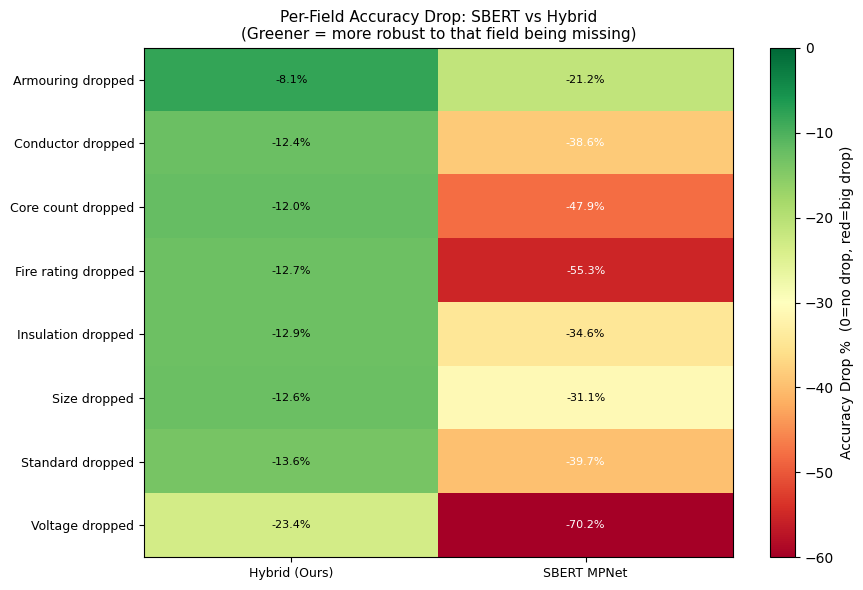

✅ Saved exp3_per_field_heatmap.png


In [ ]:
# CELL 14 — VISUALISATION 3: PER-FIELD DROP IMPACT HEATMAP
pivot = field_df.pivot(index='Field Dropped', columns='Model', values='Accuracy Drop %')

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-60, vmax=0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([c.replace(' (sem-only)','') for c in pivot.columns], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for r in range(len(pivot.index)):
    for c in range(len(pivot.columns)):
        val = pivot.values[r,c]
        if not np.isnan(val):
            ax.text(c, r, f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, color='white' if val < -35 else 'black')
plt.colorbar(im, ax=ax, label='Accuracy Drop %  (0=no drop, red=big drop)')
ax.set_title('Per-Field Accuracy Drop: SBERT vs Hybrid\n'
             '(Greener = more robust to that field being missing)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp3_per_field_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp3_per_field_heatmap.png')

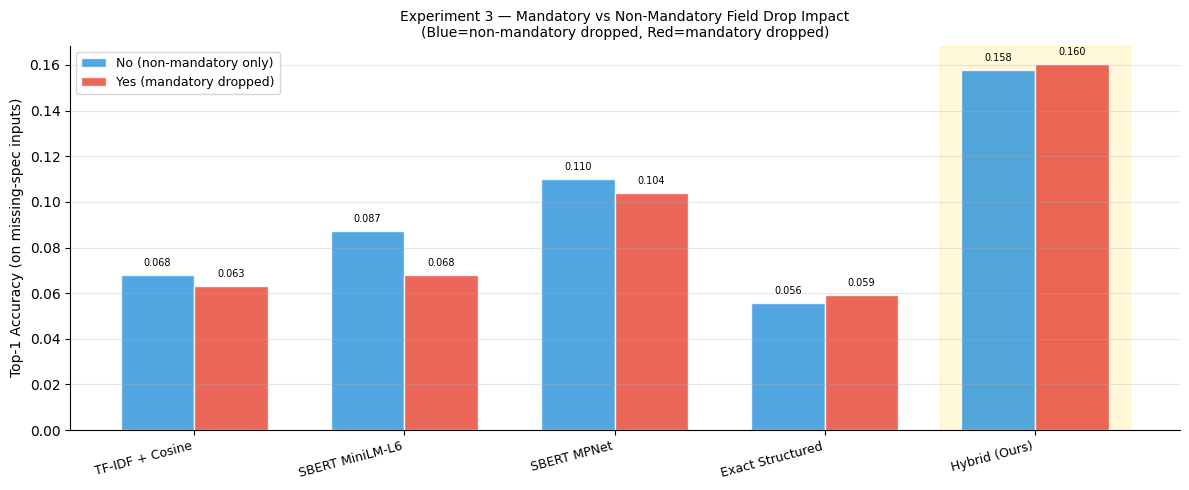

✅ Saved exp3_mandatory_vs_nonmandatory.png


In [ ]:
# CELL 15 — VISUALISATION 4: MANDATORY vs NON-MANDATORY
fig, ax = plt.subplots(figsize=(12, 5))
mand_focus = mand_df[mand_df['Model'].isin([
    'TF-IDF + Cosine','SBERT MiniLM-L6','SBERT MPNet (sem-only)',
    'Exact Structured','Hybrid (Ours)'])].copy()

categories = mand_focus['Mandatory Hit'].unique()
models_m   = mand_focus['Model'].unique()
x = np.arange(len(models_m))
w = 0.35
pal = ['#3498db','#e74c3c']
for k, (cat, color) in enumerate(zip(categories, pal)):
    sub = mand_focus[mand_focus['Mandatory Hit'] == cat]
    sub = sub.set_index('Model').loc[models_m]
    offset = (k - 0.5) * w
    bars = ax.bar(x+offset, sub['Top-1'].values, w, color=color,
                  alpha=0.85, edgecolor='white', label=cat)
    for bar, val in zip(bars, sub['Top-1'].values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

hybrid_x = list(models_m).index('Hybrid (Ours)') if 'Hybrid (Ours)' in list(models_m) else -1
if hybrid_x >= 0:
    ax.axvspan(hybrid_x-0.45, hybrid_x+0.45, color='gold', alpha=0.15, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' (sem-only)','') for m in models_m], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Top-1 Accuracy (on missing-spec inputs)')
ax.set_title('Experiment 3 — Mandatory vs Non-Mandatory Field Drop Impact\n'
             '(Blue=non-mandatory dropped, Red=mandatory dropped)', fontsize=10)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp3_mandatory_vs_nonmandatory.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp3_mandatory_vs_nonmandatory.png')

In [ ]:
# CELL 16 — CONCRETE CASES: WHERE HYBRID HOLDS, SBERT FAILS
print('=== Cases where SBERT degrades but Hybrid maintains correct match ===\n')

def top1_sku(groups, rfp_id, score_key):
    grp = groups[rfp_id]
    idx = np.lexsort((grp['sku_id'], -grp[score_key]))[0]
    return grp['sku_id'][idx]

# Find RFPs where SBERT top-1 changes but Hybrid top-1 stays
hybrid_wins = []
for rfp_id in list(gt_lookup.keys()):
    sbert_clean   = top1_sku(groups_clean,   rfp_id, 'semantic')
    sbert_missing = top1_sku(groups_missing, rfp_id, 'semantic')
    hybrid_clean  = top1_sku(groups_clean,   rfp_id, 'hybrid')
    hybrid_miss   = top1_sku(groups_missing, rfp_id, 'hybrid')
    gt            = gt_lookup[rfp_id]
    if sbert_clean != sbert_missing and hybrid_clean == hybrid_miss:
        hybrid_wins.append(rfp_id)

print(f'RFPs where SBERT rank shifts but Hybrid stays stable: {len(hybrid_wins)}\n')

for rfp_id in hybrid_wins[:8]:
    rfp_idx = df_clean[df_clean['rfp_id'] == rfp_id].index[0]
    sv_row  = sev_df[sev_df['rfp_id'] == rfp_id].iloc[0]
    orig    = df_clean.loc[rfp_idx, 'spec_text_raw']
    miss    = df_missing.loc[rfp_idx, 'spec_text_raw']
    dropped = sv_row['dropped']
    gt      = gt_lookup[rfp_id]

    sc_clean = groups_clean[rfp_id]['semantic']
    sc_miss  = groups_missing[rfp_id]['semantic']
    hc_clean = groups_clean[rfp_id]['hybrid']
    hc_miss  = groups_missing[rfp_id]['hybrid']
    skus     = groups_clean[rfp_id]['sku_id']

    sbert_t1_c = skus[np.lexsort((skus, -sc_clean))[0]]
    sbert_t1_m = skus[np.lexsort((skus, -sc_miss))[0]]
    hybrid_t1_c = skus[np.lexsort((skus, -hc_clean))[0]]
    hybrid_t1_m = skus[np.lexsort((skus, -hc_miss))[0]]

    print(f'  RFP: {rfp_id}  |  Dropped: {", ".join(dropped)}  |  GT: {gt}')
    print(f'  ORIG  : {orig}')
    print(f'  MISS  : {miss}')
    print(f'  SBERT  clean top-1={sbert_t1_c}  missing top-1={sbert_t1_m}  (changed={sbert_t1_c != sbert_t1_m}) X')
    print(f'  Hybrid clean top-1={hybrid_t1_c}  missing top-1={hybrid_t1_m}  (changed={hybrid_t1_c != hybrid_t1_m}) OK')
    print()

=== Cases where SBERT degrades but Hybrid maintains correct match ===

RFPs where SBERT rank shifts but Hybrid stays stable: 3654

  RFP: RFP_0001  |  Dropped: insulation  |  GT: SKU_268
  ORIG  : FRLS 1.1kV 4C 0.75 sqmm Cu PVC armoured cable as per IEC 60502-1
  MISS  : FRLS 1.1kV 4C 0.75 sqmm Cu armoured cable as per IEC 60502-1
  SBERT  clean top-1=SKU_296  missing top-1=SKU_161  (changed=True) X
  Hybrid clean top-1=SKU_269  missing top-1=SKU_269  (changed=False) OK

  RFP: RFP_0002  |  Dropped: core_count, conductor, insulation  |  GT: SKU_223
  ORIG  : 1.1kV 8C 6 sqmm Cu PVC armoured cable as per BS 5308
  MISS  : 1.1kV 6 sqmm armoured cable as per BS 5308
  SBERT  clean top-1=SKU_223  missing top-1=SKU_137  (changed=True) X
  Hybrid clean top-1=SKU_277  missing top-1=SKU_277  (changed=False) OK

  RFP: RFP_0006  |  Dropped: voltage, conductor  |  GT: SKU_240
  ORIG  : ZH 132kV 1C 800 sqmm Al XLPE armoured cable as per IEC 60840
  MISS  : ZH 1C 800 sqmm XLPE armoured cable as per

In [ ]:
# CELL 17 — FINAL SUMMARY (PAPER-READY)
print('\n' + '='*115)
print('  EXPERIMENT 3 — MISSING PARAMETER TEST: COMPLETE RESULTS SUMMARY')
print('='*115)

print('\n-- Section A: Overall Accuracy Drop % --')
print(ir_df[['Model','Top-1 (Clean)','Top-1 (Missing)','Accuracy Drop %',
              'MRR (Clean)','MRR (Missing)','MRR Drop %',
              'NDCG@5 (Clean)','NDCG@5 (Missing)','NDCG Drop %']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n-- Section B: Severity-Stratified (Hybrid vs SBERT MPNet) --')
for model in ['SBERT MPNet (sem-only)', 'Hybrid (Ours)']:
    sub = sev_metrics[sev_metrics['Model'] == model][['n_dropped','Top-1','MRR','NDCG@5']]
    print(f'  {model}:')
    print(sub.to_string(index=False))
    print()

# Key numbers
h = ir_df[ir_df['Model'] == 'Hybrid (Ours)'].iloc[0]
s = ir_df[ir_df['Model'] == 'SBERT MPNet (sem-only)'].iloc[0]
h_ret = h['Top-1 (Missing)'] / h['Top-1 (Clean)'] * 100 if h['Top-1 (Clean)'] > 0 else 0
s_ret = s['Top-1 (Missing)'] / s['Top-1 (Clean)'] * 100 if s['Top-1 (Clean)'] > 0 else 0

print(f'-- Key Findings --')
print(f'  SBERT  Top-1 accuracy drop: {s["Accuracy Drop %"]:+.1f}%  '
      f'(retained: {s_ret:.1f}%)')
print(f'  Hybrid Top-1 accuracy drop: {h["Accuracy Drop %"]:+.1f}%  '
      f'(retained: {h_ret:.1f}%)')
print(f'  SBERT  NDCG@5 drop: {s["NDCG Drop %"]:+.1f}%')
print(f'  Hybrid NDCG@5 drop: {h["NDCG Drop %"]:+.1f}%')
print(f'  RFPs where Hybrid stable, SBERT shifts: {len(hybrid_wins)}')
print(f'  Robustness ratio (Hybrid/SBERT retained Top-1): {h_ret/s_ret:.2f}x')


  EXPERIMENT 3 — MISSING PARAMETER TEST: COMPLETE RESULTS SUMMARY

-- Section A: Overall Accuracy Drop % --
| Model                  |   Top-1 (Clean) |   Top-1 (Missing) |   Accuracy Drop % |   MRR (Clean) |   MRR (Missing) |   MRR Drop % |   NDCG@5 (Clean) |   NDCG@5 (Missing) |   NDCG Drop % |
|:-----------------------|----------------:|------------------:|------------------:|--------------:|----------------:|-------------:|-----------------:|-------------------:|--------------:|
| Random Baseline        |          0.0046 |            0.0054 |           18.7500 |        0.0298 |          0.0299 |       0.4841 |           0.0160 |             0.0147 |       -8.2684 |
| TF-IDF + Cosine        |          0.1147 |            0.0660 |          -42.4658 |        0.2344 |          0.1549 |     -33.9419 |           0.2267 |             0.1416 |      -37.5518 |
| BM25 (Okapi)           |          0.0559 |            0.0477 |          -14.5780 |        0.1651 |          0.1312 |     -20.5169

In [ ]:
# CELL 18 — EXPORT
ir_df.to_csv(f'{EXP_DIR}/exp3_ir_metrics_clean_vs_missing.csv', index=False)
sev_metrics.to_csv(f'{EXP_DIR}/exp3_severity_stratified.csv', index=False)
mand_df.to_csv(f'{EXP_DIR}/exp3_mandatory_impact.csv', index=False)
field_df.to_csv(f'{EXP_DIR}/exp3_per_field_impact.csv', index=False)
sev_df.to_csv(f'{EXP_DIR}/exp3_per_rfp_severity.csv', index=False)

print('✅ Saved:')
for f in sorted(os.listdir(EXP_DIR)):
    size = os.path.getsize(f'{EXP_DIR}/{f}') / 1024
    print(f'   {EXP_DIR}/{f}  ({size:.0f} KB)')

✅ Saved:
   exp3_missing_params/exp3_accuracy_drop.png  (140 KB)
   exp3_missing_params/exp3_ir_metrics_clean_vs_missing.csv  (2 KB)
   exp3_missing_params/exp3_mandatory_impact.csv  (1 KB)
   exp3_missing_params/exp3_mandatory_vs_nonmandatory.png  (95 KB)
   exp3_missing_params/exp3_per_field_heatmap.png  (95 KB)
   exp3_missing_params/exp3_per_field_impact.csv  (2 KB)
   exp3_missing_params/exp3_per_rfp_severity.csv  (665 KB)
   exp3_missing_params/exp3_severity_curves.png  (191 KB)
   exp3_missing_params/exp3_severity_stratified.csv  (2 KB)
